In [1]:
import os
os.environ["PYMBAR_DISABLE_JAX"] = "1"
import BioSimSpace as BSS

INFO:rdkit:Enabling RDKit 2025.03.6 jupyter extensions
INFO:numexpr.utils:Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


We can use `BioSimSpace.FreeEnergy.Relative.analyse` function to analyse our short free energy calculation:

In [2]:
pmf, overlap = BSS.FreeEnergy.Relative.analyse("../02_simulation/OMTKY3-L18P_k_125_de_50_repl_1/")

Once the MBAR analysis is complete, we can extract our dG value:

In [3]:
BSS.FreeEnergy.Relative.difference(pmf)[0].value()

43.29420447233057

We can also use `BioSimSpace.Notebook.plotOverlapMatrix()` function to visualize the overlap matrix

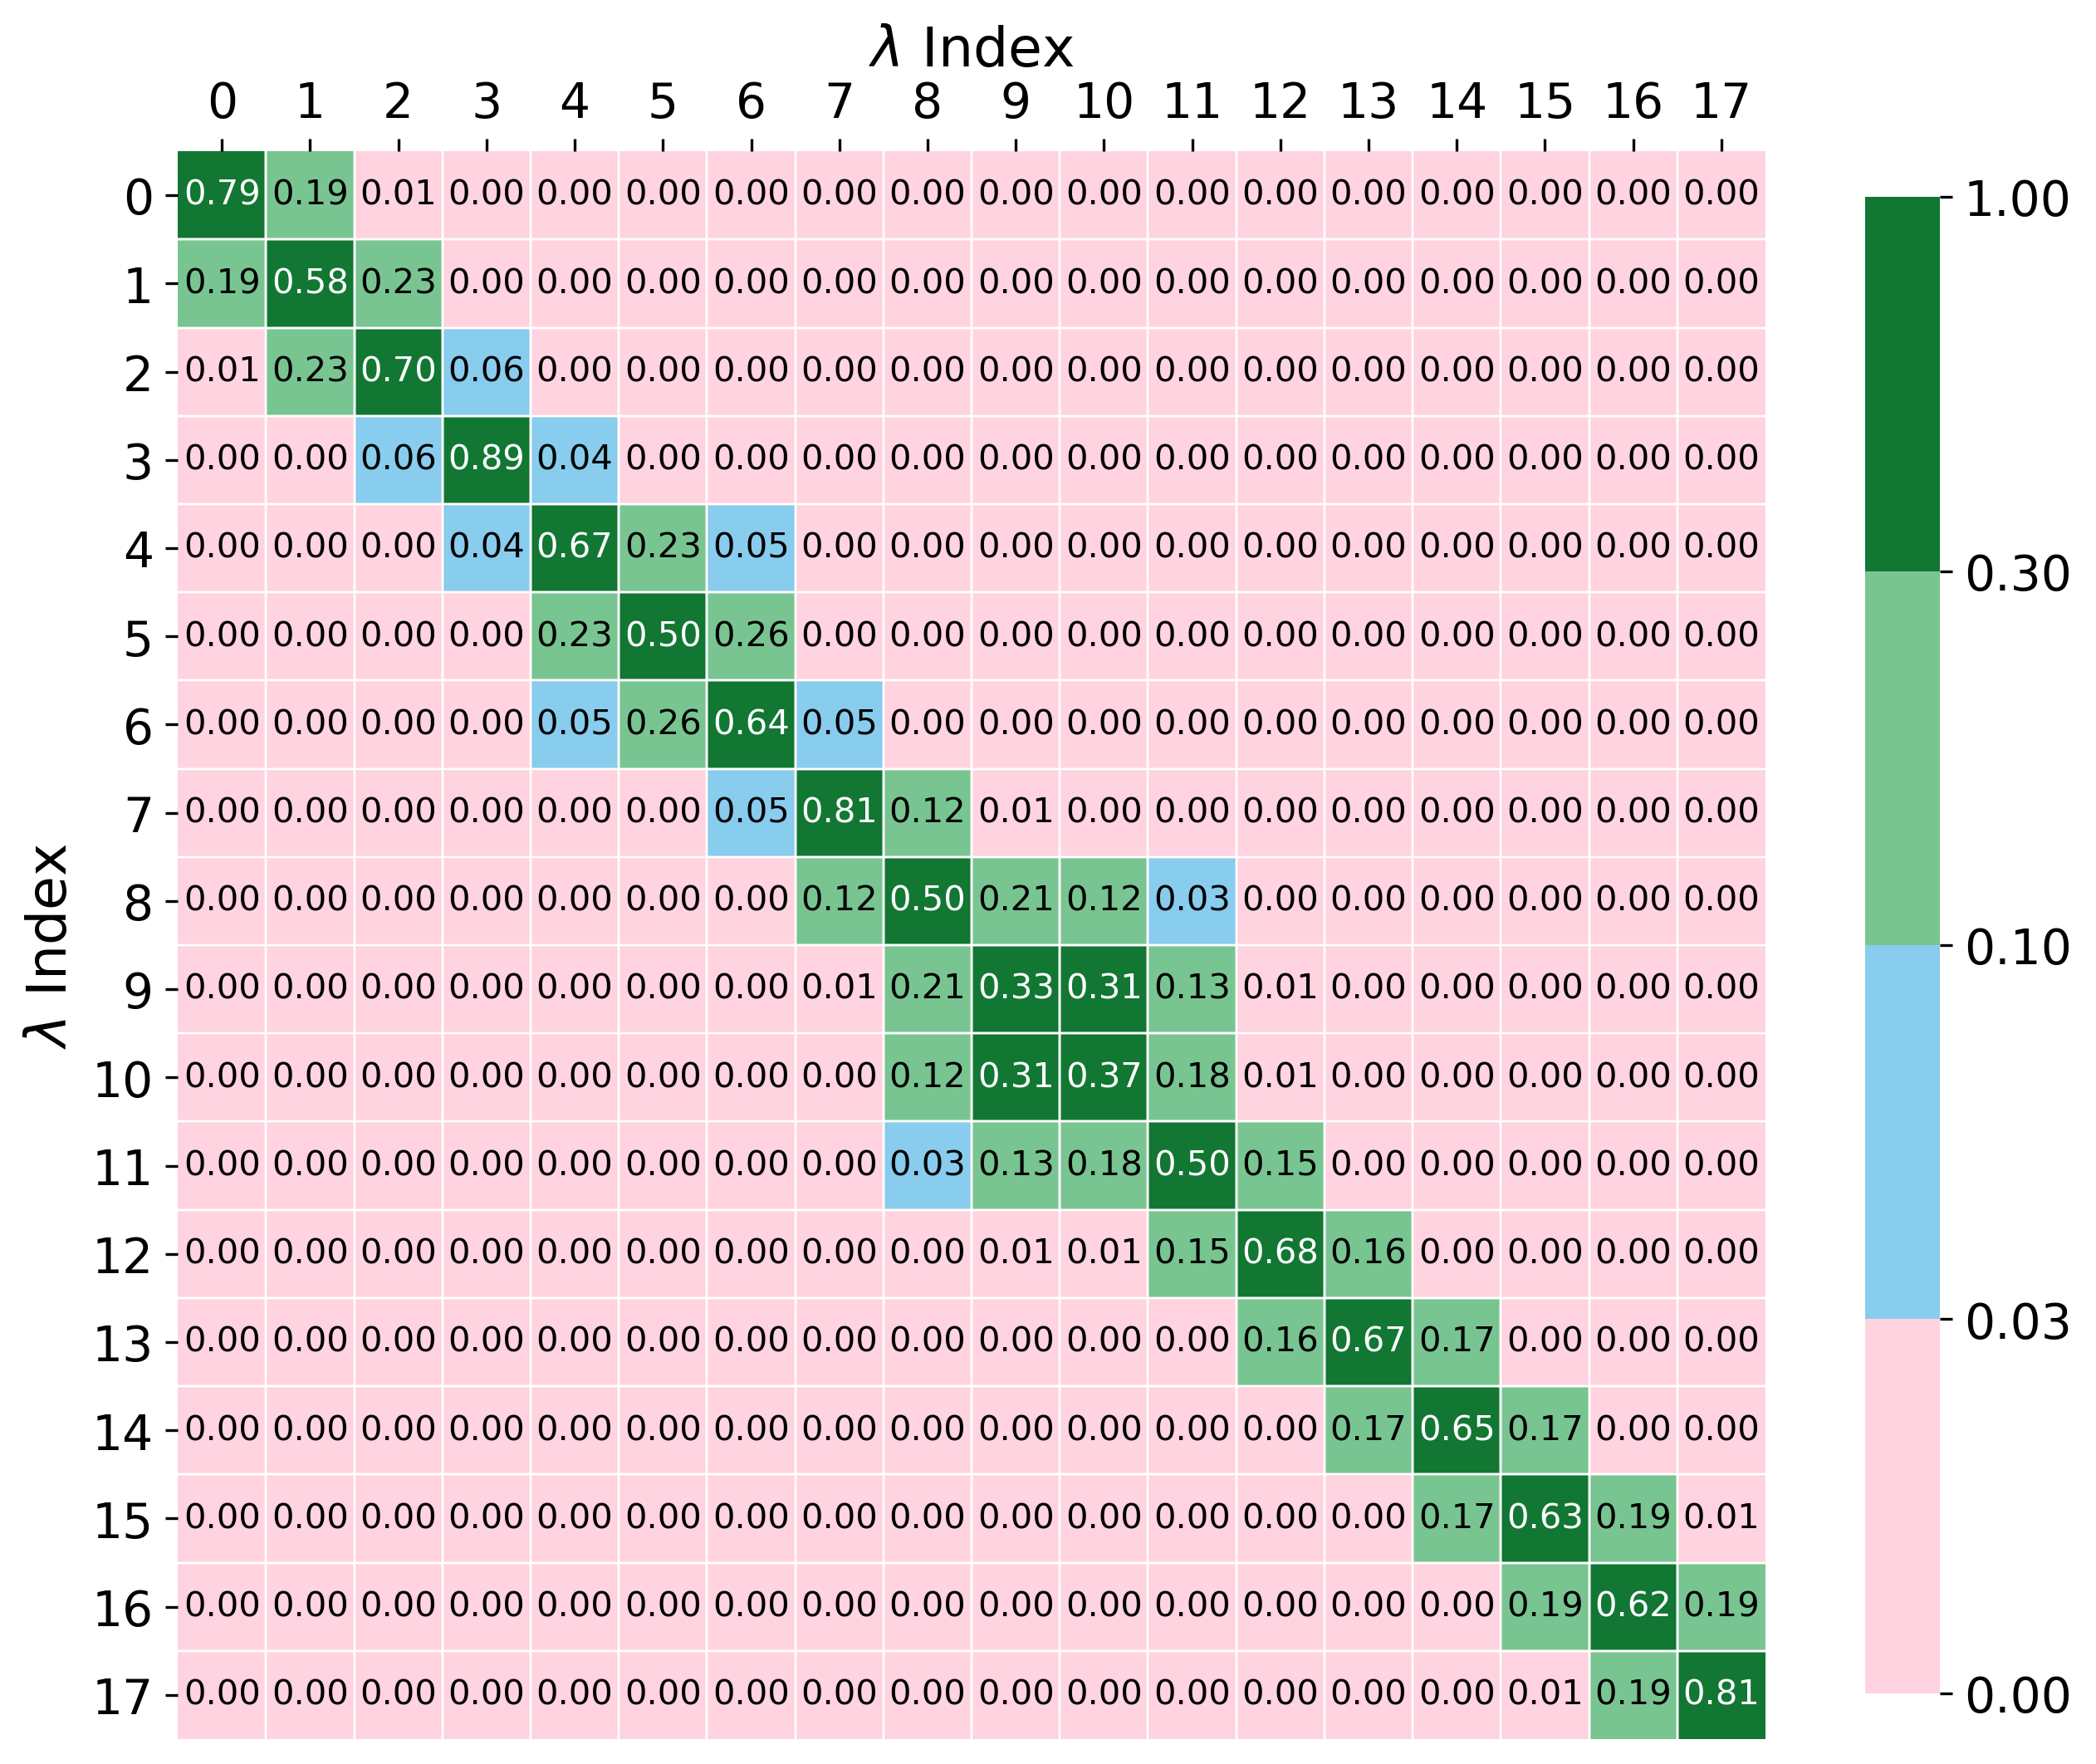

In [4]:
BSS.Notebook.plotOverlapMatrix(overlap)

We can also analyse the alchemical bond distance as a function of $\lambda$. The SOMD2 run script told us the atom indices for which the Morse potential was being applied:

```python
MorsePotentialRestraints( name=morse_hard, size=1, use_pbc=use_pbc=False
0: MorsePotentialRestraint( 207 <=> 210, k=620 kcal mol-1 Å-2 : r0=1.526 Å : de=150 kcal mol-1 )
)
MorsePotentialRestraints( name=morse_soft, size=1, use_pbc=use_pbc=False
0: MorsePotentialRestraint( 207 <=> 210, k=125 kcal mol-1 Å-2 : r0=1.526 Å : de=50 kcal mol-1 )
)
...
```

Thus, we can use `mdtraj` to track bond distances between these atoms:

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
[207] [210]
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also 

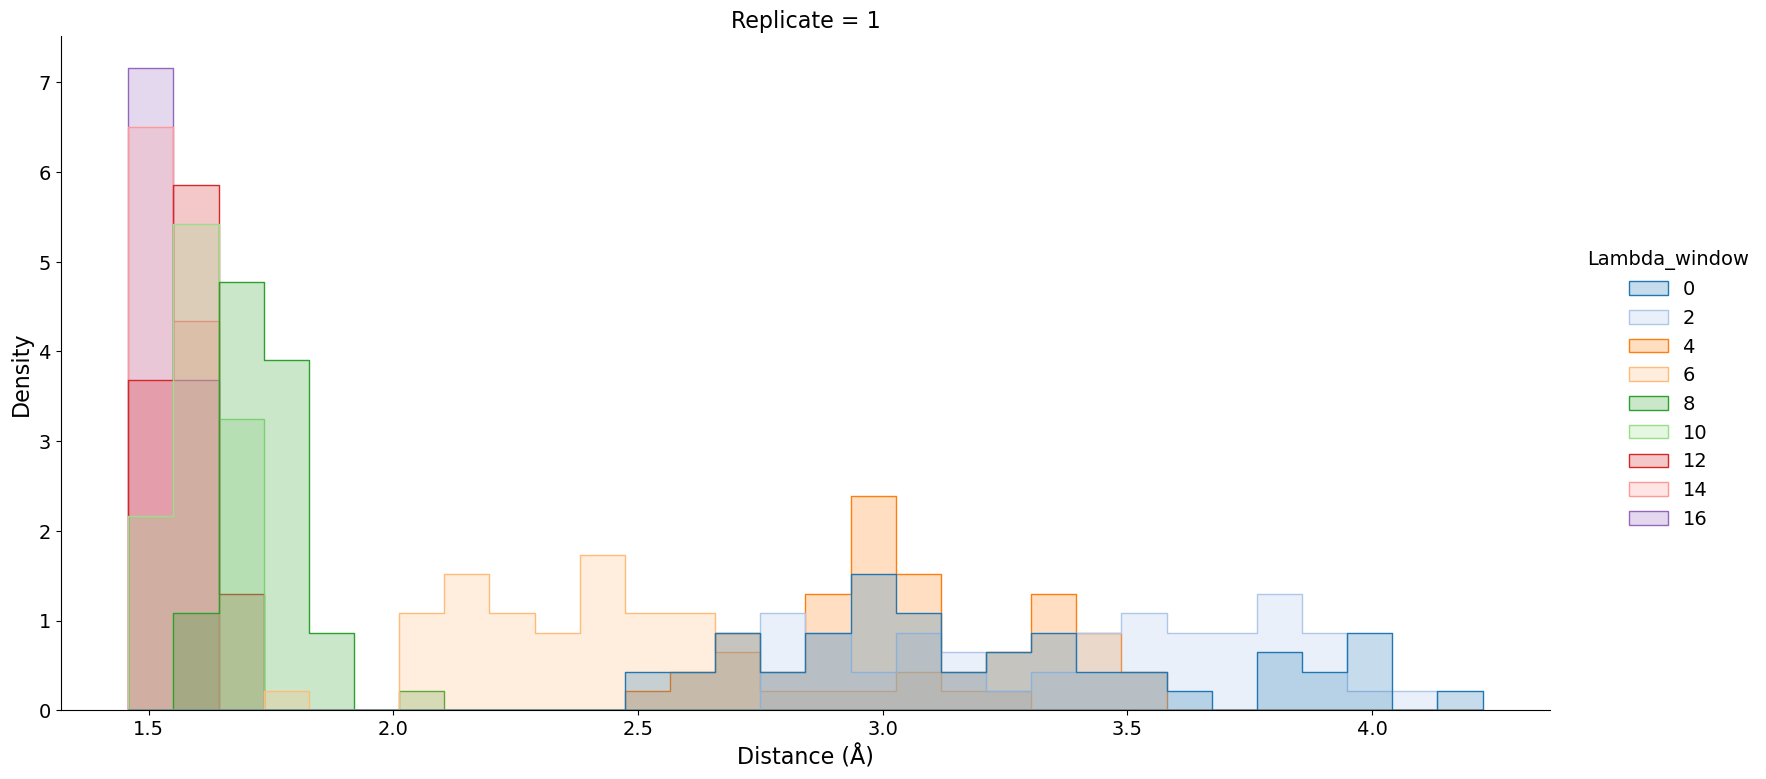

In [5]:
import numpy as np
import pandas as pd
import mdtraj as md
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob

def compute_distances(traj, topology, sel):
    """
    This function takes in a trajectory, topology of a system,  selection
    and returns two arrays, one with trajectory time and another of distances for each frame in the trajectory.
    """
    traj = md.load(traj, top=topology)
    traj_time = traj.time

    distances = md.compute_distances(traj, sel)

    # convert to angstroms
    distances = distances * 10

    return traj_time, distances


work_dir = f"../02_simulation/OMTKY3-L18P_k_125_de_50_repl_1/"
topology = f"{work_dir}/system0.prm7"

combined_dfs = []

trajs = glob(f"{work_dir}/traj_**.dcd")
trajs = sorted(trajs, key=lambda x: float(x.split("_")[-1].strip(".dcd")))

traj_init = md.load(trajs[0], top=topology)
top = traj_init.topology

a1 = top.select("name CG and index 207") # We can also just use the atom index, but this selection method is a bit more robust.
a2 = top.select("name H and index 210")

print(a1, a2)

sel = np.array([a1[0], a2[0]]).reshape(1, 2)

for j, traj_file in enumerate(trajs):
    # plot only every 2nd trajectory to avoid cluttering the plot
    if j % 2 != 0:
        continue
    else:
        traj_time, distances = compute_distances(traj_file, topology, sel)

        df = pd.DataFrame(distances, columns=["distance"])
        df["Time (ps)"] = traj_time
        df["Lambda_window"] = j
        df["Replicate"] = 1

        combined_dfs.append(df)

combined_dfs = pd.concat(combined_dfs, ignore_index=True)

g = sns.displot(
    data=combined_dfs, 
    x="distance", 
    hue="Lambda_window", 
    col="Replicate",
    kind="hist",
    element="step",
    bins=30,
    fill=True, 
    stat="density", 
    palette="tab20",
    common_norm=False, 
    height=8, 
    aspect=2)

g.set_axis_labels("Distance (Å)", "Density")
plt.show()

We can see that because we are forming a bond, the bond distance decreases as a function of $\lambda$, and the final $\lambda$ windows sample bond distances around $r_0=1.526$ as defined in the Morse potential.

In [6]:
combined_dfs

,distance,Time (ps),Lambda_window,Replicate
0,3.318870,0,0,1
1,3.192680,1,0,1
2,3.987279,2,0,1
3,2.983343,3,0,1
4,3.403559,4,0,1
...,...,...,...,...
445,1.523836,45,16,1
446,1.508421,46,16,1
447,1.528878,47,16,1
448,1.567275,48,16,1
